# Lab: Build a dense variational autoencoder for faces

**Time:** 90–120 minutes  
**Prerequisites:** PyTorch, linear layers, probability basics, and gradient descent

In this lab you will turn an image into a *distribution* in latent space, sample from
that distribution with the reparameterization trick, and train a decoder using the
VAE objective. The network is deliberately fully connected: convolution is useful
for images, but it is not what makes a model a VAE.

By the end, you should be able to:

- distinguish a deterministic autoencoder from a VAE;
- parameterize $q_\phi(z\mid x)$ with $\mu$ and $\log\sigma^2$;
- implement $z=\mu+\sigma\odot\epsilon$ without breaking backpropagation;
- combine reconstruction and KL-divergence terms; and
- generate new faces by sampling $z\sim\mathcal N(0,I)$.


## 1. Environment and LFW data (10 minutes)

This notebook runs both on Kaggle and locally.

**On Kaggle:** create a notebook, choose **Add Input**, search for `LFW Dataset`, and
attach the dataset whose mounted folder is `/kaggle/input/lfw-dataset`. Upload this
notebook or open it from the course repository, then choose a GPU accelerator if one
is available. No path edit should be necessary.

**Locally:** download and extract LFW so the directory contains person folders and
`.jpg` files. Then either:

1. set the environment variable `LFW_DATASET_PATH` to the extracted directory; or
2. edit `LOCAL_DATASET_PATH` in the next cell.

The path may point either directly to `lfw-deepfunneled` or to a parent directory;
the discovery code searches below it. The notebook fails early with a useful message
if no images are found.


In [22]:
# Kaggle images normally include these packages. For a minimal local environment:
# %pip install torch torchvision matplotlib pandas scikit-learn pillow

import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 45
CHANNELS = 3
INPUT_DIM = CHANNELS * IMAGE_SIZE * IMAGE_SIZE
LATENT_DIM = 100
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
BETA = 1.0
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

# Change only this line for a local setup if LFW_DATASET_PATH is not set.
LOCAL_DATASET_PATH = Path("data/lfw-deepfunneled")

print(f"Running on {DEVICE}")


Running on cuda


In [23]:
import os
os.environ["LFW_DATASET_PATH"] = "/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"

In [24]:
def resolve_lfw_root():
    env_path = os.environ.get("LFW_DATASET_PATH")
    candidates = []
    if env_path:
        candidates.append(Path(env_path).expanduser())
    if Path("/kaggle/input").exists():
        candidates.extend([
            Path("/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"),
            Path("/kaggle/input/lfw-dataset"),
        ])
    candidates.extend([
        LOCAL_DATASET_PATH.expanduser(),
        Path("lfw-deepfunneled"),
    ])

    for root in candidates:
        if root.exists() and next(root.rglob("*.jpg"), None) is not None:
            return root
    checked = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(
        "No LFW .jpg files were found. Attach lfw-dataset on Kaggle, set "
        "LFW_DATASET_PATH, or edit LOCAL_DATASET_PATH. Checked:\n" + checked
    )


DATASET_ROOT = resolve_lfw_root()
image_paths = sorted(DATASET_ROOT.rglob("*.jpg"))
image_df = pd.DataFrame({
    "path": image_paths,
    "person": [path.parent.name for path in image_paths],
})

# Preserve the original notebook's balancing choice: remove identities with 25+
# photographs so a few celebrities do not dominate reconstruction training.
image_df = image_df.groupby("person", group_keys=False).filter(lambda rows: len(rows) < 25)
image_df = image_df.reset_index(drop=True)

print(f"Dataset root: {DATASET_ROOT}")
print(f"Using {len(image_df):,} images from {image_df['person'].nunique():,} people")
image_df.head()


Dataset root: /kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled
Using 10,645 images from 5,707 people


,path,person
0,/kaggle/input/datasets/jessicali9530/lfw-datas...,AJ_Cook
1,/kaggle/input/datasets/jessicali9530/lfw-datas...,AJ_Lamas
2,/kaggle/input/datasets/jessicali9530/lfw-datas...,Aaron_Eckhart
3,/kaggle/input/datasets/jessicali9530/lfw-datas...,Aaron_Guiel
4,/kaggle/input/datasets/jessicali9530/lfw-datas...,Aaron_Patterson


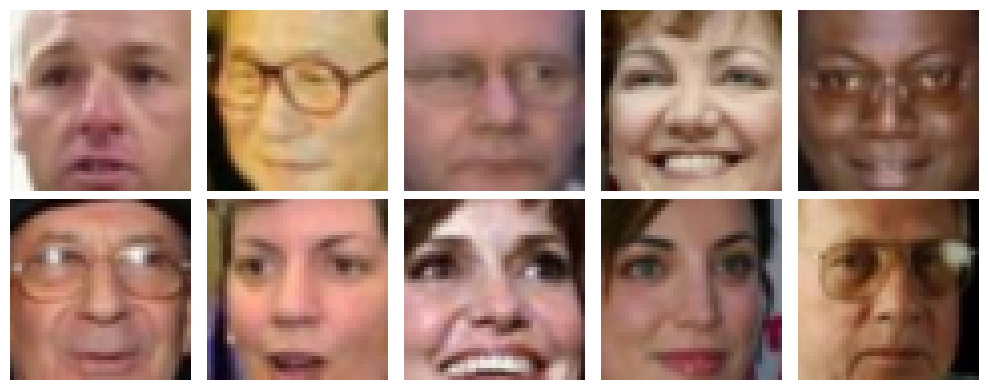

In [4]:
class FaceDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        path = self.dataframe.loc[index, "path"]
        with Image.open(path) as image:
            image = image.convert("RGB")
            # LFW deep-funneled images are 250x250. This reproduces the original
            # notebook's central crop while remaining safe for other image sizes.
            width, height = image.size
            margin_x = min(80, max(0, (width - 1) // 3))
            margin_y = min(80, max(0, (height - 1) // 3))
            image = image.crop((margin_x, margin_y, width - margin_x, height - margin_y))
            return self.transform(image)


transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),  # pixel values in [0, 1]
])

train_df, val_df = train_test_split(image_df, test_size=0.2, random_state=SEED)
train_dataset = FaceDataset(train_df, transform)
val_dataset = FaceDataset(val_df, transform)

loader_args = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda")
train_loader = DataLoader(train_dataset, shuffle=True, **loader_args)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_args)

faces = next(iter(train_loader))
assert faces.ndim == 4 and faces.shape[1:] == (3, 45, 45)
assert 0 <= faces.min() and faces.max() <= 1

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for face, axis in zip(faces[:10], axes.flat):
    axis.imshow(face.permute(1, 2, 0))
    axis.axis("off")
plt.tight_layout()


## 2. From autoencoder to VAE (10 minutes)

A deterministic autoencoder maps $x$ to one vector $z$. A VAE encoder instead
describes a diagonal Gaussian approximate posterior:

$$q_\phi(z\mid x)=\mathcal N\left(\mu_\phi(x),\operatorname{diag}(\sigma_\phi^2(x))\right).$$

We predict `logvar` rather than variance because it may take any real value and is
numerically convenient. For a batch of `N` images and `LATENT_DIM = 100`, answer:

1. What are the shapes of `mu`, `logvar`, and `z`?
2. Why must the final `mu` and `logvar` layers have no ReLU?
3. Why does directly drawing `z` from a distribution parameterized by the encoder
   make ordinary backpropagation difficult?

Write your answers in a new Markdown cell.


1. Shapes of mu, logvar and z will be (N, 100) where N = batch size and 100 is the latent dimension.
2. Main purpose of adding ReLU is to eliminate negative values in result, if there is no ReLU layer than final answer can also have negative values.
3. Random sampling is a non-differentiable operation, thus, gradient can't go back through it while backpropogation, hence model will never actually be trained.

## 3. Implement the probabilistic encoder (25 minutes)

**TODO 1:** Add two linear heads that map the shared 1000-unit representation to
`LATENT_DIM`: one for `mu` and one for `logvar`.

**TODO 2:** Implement the reparameterization trick. Compute
$\sigma=\exp(\tfrac12\log\sigma^2)$, draw $\epsilon$ with `torch.randn_like`, and
return $\mu+\sigma\epsilon$.

**TODO 3:** Complete `forward`: encode, sample, decode, and return
`reconstruction, mu, logvar`. The decoder returns probabilities in `[0, 1]`, so its
last operation is a sigmoid.


In [5]:
class DenseFaceVAE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1500),
            nn.ReLU(),
            nn.Linear(1500, 1000),
            nn.ReLU(),
        )

        # TODO 1: define self.mu_head and self.logvar_head.
        self.mu_head = nn.Linear(1000, latent_dim)
        self.logvar_head = nn.Linear(1000, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 1000),
            nn.ReLU(),
            nn.Linear(1000, 1500),
            nn.ReLU(),
            nn.Linear(1500, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        features = self.encoder(x.flatten(start_dim=1))
        return self.mu_head(features), self.logvar_head(features)

    def reparameterize(self, mu, logvar):
        # TODO 2: sample z while preserving a differentiable path to mu/logvar.
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        pixels = self.decoder(z)
        return pixels.view(-1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE)

    def forward(self, x):
        # TODO 3: encode x, sample z, decode it, and return all three outputs.
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar


In [6]:
# These checks give fast feedback before expensive training.
model = DenseFaceVAE().to(DEVICE)
test_batch = faces[:4].to(DEVICE)
reconstruction, mu, logvar = model(test_batch)

assert reconstruction.shape == test_batch.shape
assert mu.shape == logvar.shape == (4, LATENT_DIM)
assert reconstruction.min() >= 0 and reconstruction.max() <= 1

# Sampling should normally give different z values, while gradients still reach
# both distribution heads.
z1 = model.reparameterize(mu, logvar)
z2 = model.reparameterize(mu, logvar)
assert not torch.equal(z1, z2)
(z1.mean()).backward()
assert model.mu_head.weight.grad is not None
assert model.logvar_head.weight.grad is not None
model.zero_grad(set_to_none=True)
print("Model checks passed.")


Model checks passed.


## 4. Implement the negative ELBO (20 minutes)

For this Bernoulli observation model, minimize

$$
\mathcal L = \underbrace{\operatorname{BCE}(\hat x,x)}_{\text{reconstruction}}
+\beta\underbrace{D_{KL}\!\left(q_\phi(z\mid x)\,\|\,\mathcal N(0,I)\right)}_{\text{regularization}}.
$$

For a diagonal Gaussian,

$$D_{KL}=-\frac12\sum_j\left(1+\log\sigma_j^2-\mu_j^2-\exp(\log\sigma_j^2)\right).$$

**TODO 4:** Compute BCE and KL with `reduction="sum"`, then divide each by the
batch size so reported values are per image. Return total loss, detached
reconstruction loss, and detached KL loss. Do not detach the total loss.


In [7]:
def vae_loss(reconstruction, target, mu, logvar, beta=1.0):
    # TODO 4: implement reconstruction + beta * KL, normalized per image.
    batch_size = target.size(0)
    recon_loss = F.binary_cross_entropy(reconstruction, target, reduction="sum") / batch_size
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size
    total = recon_loss + beta * kl_loss
    return total, recon_loss.detach(), kl_loss.detach()


In [8]:
# At mu=0 and logvar=0, q(z|x) equals the unit-normal prior, so KL must be zero.
dummy_x = torch.full((2, 3, 45, 45), 0.5, device=DEVICE)
dummy_mu = torch.zeros(2, LATENT_DIM, device=DEVICE)
dummy_logvar = torch.zeros_like(dummy_mu)
total, recon_term, kl_term = vae_loss(dummy_x, dummy_x, dummy_mu, dummy_logvar)
assert torch.isclose(kl_term, torch.tensor(0.0, device=DEVICE))
assert total.requires_grad is False  # dummy tensors do not require gradients

# With model outputs, the total must carry a gradient path.
reconstruction, mu, logvar = model(test_batch)
total, _, _ = vae_loss(reconstruction, test_batch, mu, logvar, beta=BETA)
assert total.requires_grad
print("Loss checks passed.")


Loss checks passed.


## 5. Train the VAE (20–30 minutes)

**TODO 5:** Complete one training step: move the batch to the device, clear old
gradients, run the model, compute the VAE loss, backpropagate, and update parameters.

The reconstruction term sums over 6075 pixels, whereas KL sums over 100 latent
dimensions, so their magnitudes will differ. Track them separately. Ten epochs are a
starting point; reduce `EPOCHS` for a smoke test or increase it for better faces.


In [9]:
def train_step(model, batch, optimizer, beta):
    # TODO 5: implement one optimization step and return three Python floats.
    batch = batch.to(DEVICE, non_blocking=True)
    optimizer.zero_grad()
    reconstruction, mu, logvar = model(batch)
    total, recon_term, kl_term = vae_loss(reconstruction, batch, mu, logvar, beta)
    total.backward()
    optimizer.step()
    return total.item(), recon_term.item(), kl_term.item()


Epoch 01 | train 3999.20 | val 3962.68 | recon 3948.14 | KL 3.63
Epoch 02 | train 3958.20 | val 3950.99 | recon 3936.23 | KL 3.69
Epoch 03 | train 3918.57 | val 3890.71 | recon 3863.35 | KL 6.84
Epoch 04 | train 3890.22 | val 3873.22 | recon 3849.23 | KL 6.00
Epoch 05 | train 3863.22 | val 3853.09 | recon 3828.08 | KL 6.25
Epoch 06 | train 3847.38 | val 3835.25 | recon 3808.31 | KL 6.73
Epoch 07 | train 3837.87 | val 3823.76 | recon 3795.94 | KL 6.96
Epoch 08 | train 3833.46 | val 3822.47 | recon 3796.57 | KL 6.47
Epoch 09 | train 3830.36 | val 3827.93 | recon 3799.19 | KL 7.18
Epoch 10 | train 3826.34 | val 3831.79 | recon 3802.79 | KL 7.25


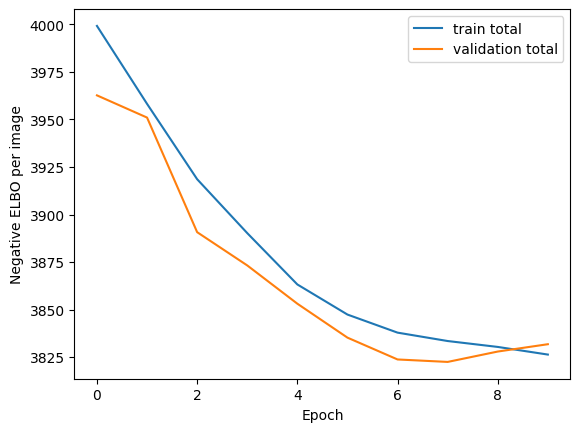

In [19]:
@torch.no_grad()
def evaluate(model, loader, beta):
    model.eval()
    totals = np.zeros(3, dtype=np.float64)
    examples = 0
    for batch in loader:
        batch = batch.to(DEVICE, non_blocking=True)
        reconstruction, mu, logvar = model(batch)
        values = vae_loss(reconstruction, batch, mu, logvar, beta)
        batch_size = batch.size(0)
        totals += np.array([value.item() for value in values]) * batch_size
        examples += batch_size
    return totals / examples


model = DenseFaceVAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"train_total": [], "val_total": [], "val_reconstruction": [], "val_kl": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_total = 0.0
    seen = 0
    for batch in train_loader:
        total, reconstruction_term, kl_term = train_step(model, batch, optimizer, BETA)
        running_total += total * batch.size(0)
        seen += batch.size(0)

    val_total, val_reconstruction, val_kl = evaluate(model, val_loader, BETA)
    history["train_total"].append(running_total / seen)
    history["val_total"].append(val_total)
    history["val_reconstruction"].append(val_reconstruction)
    history["val_kl"].append(val_kl)
    print(
        f"Epoch {epoch:02d} | train {running_total / seen:.2f} | "
        f"val {val_total:.2f} | recon {val_reconstruction:.2f} | KL {val_kl:.2f}"
    )

plt.plot(history["train_total"], label="train total")
plt.plot(history["val_total"], label="validation total")
plt.xlabel("Epoch")
plt.ylabel("Negative ELBO per image")
plt.legend()
plt.show()


## 6. Inspect reconstructions (10 minutes)

For a repeatable reconstruction we decode the posterior mean rather than a random
sample. Compare identity, pose, colour, and fine detail. Dense networks discard
spatial structure when flattening, so some blur is expected.


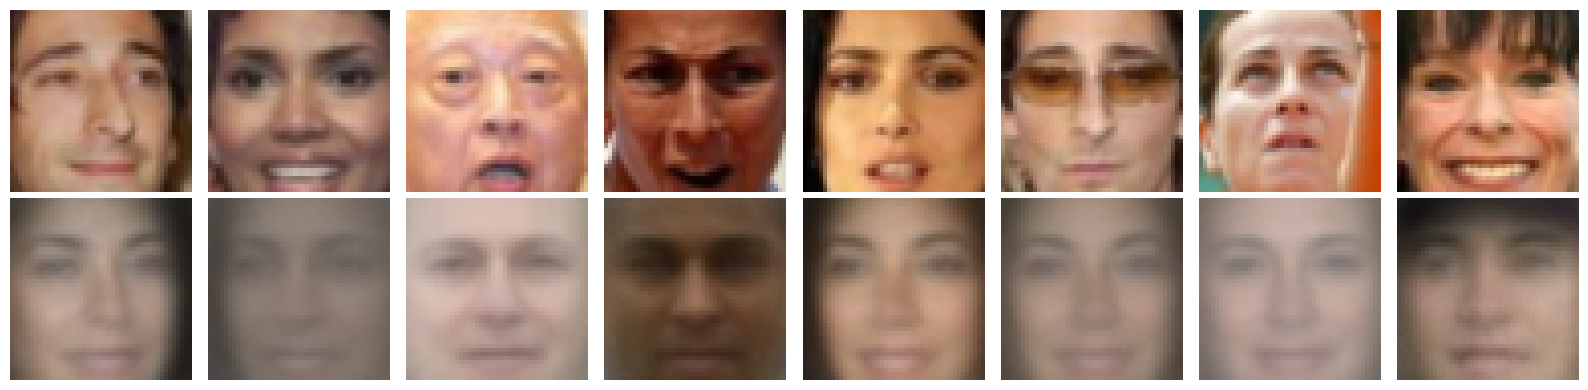

In [20]:
model.eval()
validation_faces = next(iter(val_loader))[:8].to(DEVICE)
with torch.no_grad():
    mu, _ = model.encode(validation_faces)
    reconstructed_faces = model.decode(mu)

originals = validation_faces.cpu()
reconstructed_faces = reconstructed_faces.cpu()
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for index in range(8):
    axes[0, index].imshow(originals[index].permute(1, 2, 0))
    axes[1, index].imshow(reconstructed_faces[index].permute(1, 2, 0).clamp(0, 1))
    axes[0, index].axis("off")
    axes[1, index].axis("off")
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")
plt.tight_layout()


## 7. Generate new faces (10 minutes)

Reconstruction conditions on an existing face. Generation does not: it draws from
the prior and sends those latent vectors directly to the decoder.

**TODO 6:** Sample 10 latent vectors from $\mathcal N(0,I)$ on `DEVICE`, decode them,
and store the result in `generated_faces`. Then run the visualization cell.


In [12]:
model.eval()
with torch.no_grad():
    # TODO 6: sample from the prior and decode.
    z = torch.randn(10, LATENT_DIM, device=DEVICE)
    generated_faces = model.decode(z)


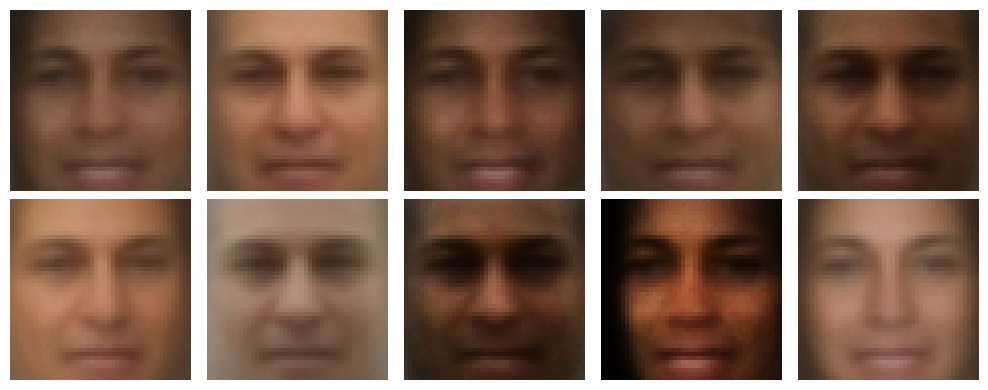

In [21]:
assert generated_faces.shape == (10, 3, 45, 45)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for face, axis in zip(generated_faces.cpu(), axes.flat):
    axis.imshow(face.permute(1, 2, 0).clamp(0, 1))
    axis.axis("off")
plt.tight_layout()


## 8. Experiment: what does $\beta$ control? (15–30 minutes)

Train fresh models using two of `BETA = 0`, `0.1`, `1`, or `4`, keeping all other
settings fixed. Record validation reconstruction, validation KL, and visual quality
of prior samples.

| $\beta$ | Reconstruction | KL | Prior-sample observations |
|---:|---:|---:|---|
| | | | |
| | | | |

Answer in a Markdown cell:

1. What happens at $\beta=0$, and why is that model no longer encouraged to have a
   sampleable unit-normal latent space?
2. How does increasing $\beta$ change reconstruction fidelity and prior samples?
3. Why can a VAE be implemented without convolutional layers? What disadvantage does
   this dense model have for images?

### Optional extensions

- Interpolate between the posterior means of two validation faces and decode the path.
- Replace the dense encoder/decoder with convolutional layers without changing the
  probabilistic heads, reparameterization, or loss.
- Add KL warm-up: increase $\beta$ gradually from 0 to 1 during early epochs.


| β | Reconstruction | KL | Prior-sample observations |
|---:|---:|---:|---|
| 0 | 3746.13 | 284.51 | Latent space not close to N(0,I), so random samples don't match trained space — generated faces look noisy/broken, not face-like |
| 1 | 3781.63 | 15.74 | Latent space reasonably close to N(0,I) — generated faces look blurry but face-like |
| 4 | 3802.79 | 7.25 | Latent space very close to N(0,I) — generated faces look smooth/generic but reconstruction quality drops |

1. At beta = 0, the model does not care about the KL term at all, only reconstruction. So it does not push the latent space to look like a normal distribution. KL value stays very high (284), meaning random samples from N(0,I) will not match what the encoder actually learned.
2. As beta goes up, KL goes down a lot (284 → 15.74 → 7.25) and reconstruction loss goes up (3746 → 3781 → 3802). So higher β gives better/more usable random samples but worse, blurrier reconstructions.
3. A VAE just needs an encoder that outputs mu and logvar, and a decoder that turns z back into an image. Any type of layer, dense or conv, can do this. The disadvantage of dense layers is that they flatten the image and lose spatial structure (which pixels are near which), so results come out blurrier and less detailed than a CNN-based VAE.

## Submission and assessment

Submit the executed student notebook with:

- probabilistic encoder heads and correct tensor shapes (**1 mark**);
- reparameterization and forward pass, with checks passing (**2 marks**);
- reconstruction-plus-KL loss, with checks passing (**2 marks**);
- training step and recorded learning curves (**2 marks**);
- reconstructions and generated faces (**1 mark**); and
- the $\beta$ experiment and conceptual answers (**2 marks**).

**Total: 10 marks.**
